# BD PowerCast
## Machine Learning-Based Electricity Demand Forecasting and Load-Shedding Risk Prediction for Bangladesh

### Project Objectives

1. Analyze historical electricity demand data from Bangladesh.
2. Forecast future electricity demand using machine learning.
3. Compare different machine learning models.
4. Predict the probability of load shedding.
5. Identify the most important factors affecting electricity demand.

Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


Load the dataset

In [3]:
df = pd.read_excel("PGCB_date_power_demand.xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


first row

In [4]:
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


dataset size

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 92650
Number of columns: 15


colmun names 

In [6]:
print(df.columns.tolist())

['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']


dataset info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

basic stat

In [8]:
df.describe()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,92650,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000
mean,2020-05-17 03:52:07.609282304,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814
min,2015-04-19 00:00:00,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-10-31 06:15:00,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000
50%,2020-05-21 15:30:00,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000
75%,2022-12-03 18:22:30,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000
max,2025-06-17 12:00:00,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000
std,NaN,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897


missing values

In [9]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

nepal          87299
remarks        86257
india_adani    85312
wind           73974
solar          22133
dtype: int64

convert datetime

In [10]:
df["datetime"] = pd.to_datetime(
    df["datetime"],
    errors="coerce"
)

print(df["datetime"].dtype)

datetime64[ns]


check the date range

In [11]:
print("Starting date:", df["datetime"].min())
print("Ending date:", df["datetime"].max())

Starting date: 2015-04-19 00:00:00
Ending date: 2025-06-17 12:00:00


Sort chronologically

In [12]:
df = df.sort_values("datetime").reset_index(drop=True)

df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


Check duplicated timestamps

In [13]:
duplicate_count = df["datetime"].duplicated().sum()

print("Duplicate timestamps:", duplicate_count)



Duplicate timestamps: 432


In [14]:
duplicates = df[
    df["datetime"].duplicated(keep=False)
]

duplicates.head(20)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
76,2015-04-22 21:00:00,5811.0,5811,0,4158,1021,162,30,NaN,NaN,440,0,NaN,NaN,NaN
77,2015-04-22 21:00:00,5368.0,5368,0,4184,552,160,30,NaN,NaN,442,0,NaN,NaN,NaN
79,2015-04-23 00:00:00,5726.0,5726,0,4199,790,158,46,NaN,NaN,433,0,NaN,NaN,NaN
80,2015-04-23 00:00:00,3976.0,3976,0,3116,230,158,30,NaN,NaN,442,0,NaN,NaN,NaN
158,2015-04-27 00:00:00,5236.0,5236,0,4417,159,162,46,NaN,NaN,452,0,NaN,NaN,NaN
159,2015-04-27 00:00:00,4800.0,4800,0,3954,117,166,46,NaN,NaN,458,0,NaN,NaN,NaN
160,2015-04-27 00:00:00,5459.0,5459,0,4457,363,148,45,NaN,NaN,458,0,NaN,NaN,NaN
238,2015-04-30 00:00:00,5809.0,5809,0,4901,257,154,46,NaN,NaN,451,0,NaN,NaN,NaN
239,2015-04-30 00:00:00,6065.0,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN,NaN
240,2015-04-30 00:00:00,6889.0,6889,0,4698,1540,157,42,NaN,NaN,452,0,NaN,NaN,Evening_Peak


Check missing dates

In [15]:
df["datetime"].isnull().sum()

np.int64(0)

look at demand

In [16]:
df["datetime"].isnull().sum()

np.int64(0)

In [17]:
print("Minimum demand:", df["demand_mw"].min())
print("Maximum demand:", df["demand_mw"].max())
print("Average demand:", df["demand_mw"].mean())

Minimum demand: 6
Maximum demand: 156050
Average demand: 8819.646044252564


Visualize demand

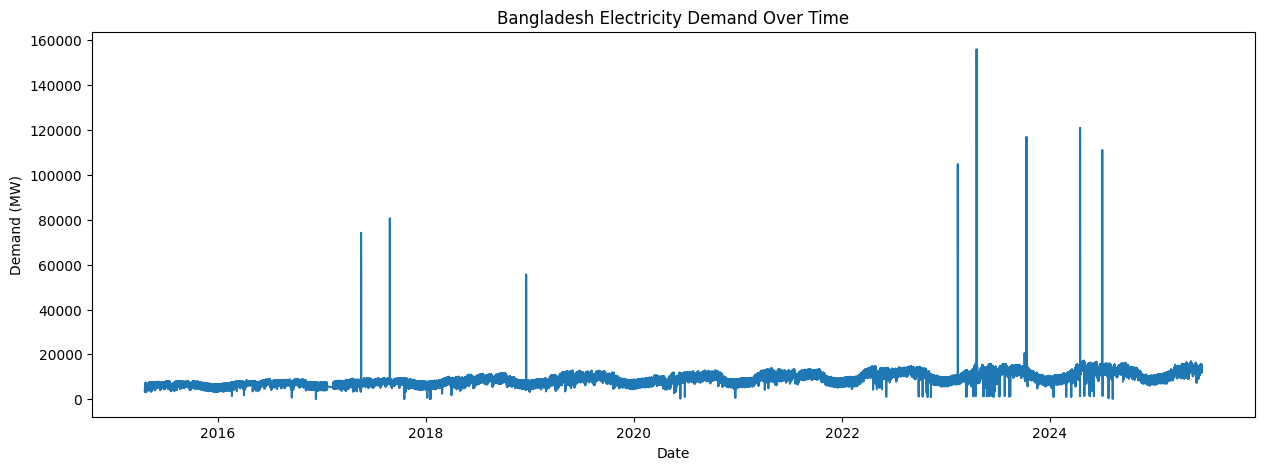

In [18]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["datetime"],
    df["demand_mw"]
)

plt.title("Bangladesh Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")

plt.show()

check load sheeding


In [19]:
df["load_shedding"].describe()

count    92650.000000
mean        81.470405
std        442.757182
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      65359.000000
Name: load_shedding, dtype: float64

In [20]:
print(
    "Rows with load shedding:",
    (df["load_shedding"] > 0).sum()
)

print(
    "Rows without load shedding:",
    (df["load_shedding"] == 0).sum()
)

Rows with load shedding: 14808
Rows without load shedding: 77842


create copy before cleaning

In [21]:
df_original = df.copy()

print("Original dataset backup created.")

Original dataset backup created.


In [22]:
df.head()
df.info()
df.describe()
df.isnull().sum()
duplicates.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
76,2015-04-22 21:00:00,5811.0,5811,0,4158,1021,162,30,NaN,NaN,440,0,NaN,NaN,NaN
77,2015-04-22 21:00:00,5368.0,5368,0,4184,552,160,30,NaN,NaN,442,0,NaN,NaN,NaN
79,2015-04-23 00:00:00,5726.0,5726,0,4199,790,158,46,NaN,NaN,433,0,NaN,NaN,NaN
80,2015-04-23 00:00:00,3976.0,3976,0,3116,230,158,30,NaN,NaN,442,0,NaN,NaN,NaN
158,2015-04-27 00:00:00,5236.0,5236,0,4417,159,162,46,NaN,NaN,452,0,NaN,NaN,NaN
159,2015-04-27 00:00:00,4800.0,4800,0,3954,117,166,46,NaN,NaN,458,0,NaN,NaN,NaN
160,2015-04-27 00:00:00,5459.0,5459,0,4457,363,148,45,NaN,NaN,458,0,NaN,NaN,NaN
238,2015-04-30 00:00:00,5809.0,5809,0,4901,257,154,46,NaN,NaN,451,0,NaN,NaN,NaN
239,2015-04-30 00:00:00,6065.0,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN,NaN
240,2015-04-30 00:00:00,6889.0,6889,0,4698,1540,157,42,NaN,NaN,452,0,NaN,NaN,Evening_Peak


In [23]:
print("Duplicate timestamps:", duplicate_count)
print("Starting date:", df["datetime"].min())
print("Ending date:", df["datetime"].max())

Duplicate timestamps: 432
Starting date: 2015-04-19 00:00:00
Ending date: 2025-06-17 12:00:00


phase-2

Create the working dataframe

In [24]:
df_clean = df.copy()

print("Working copy created.")
print("Shape:", df_clean.shape)

Working copy created.
Shape: (92650, 15)


check completely identical rows

In [25]:
exact_duplicates = df_clean.duplicated().sum()

print("Completely identical duplicate rows:", exact_duplicates)

Completely identical duplicate rows: 160


Count unique timestamps

In [26]:
print("Total rows:", len(df_clean))
print("Unique timestamps:", df_clean["datetime"].nunique())
print(
    "Rows involved in duplicate timestamps:",
    df_clean["datetime"].duplicated(keep=False).sum()
)

Total rows: 92650
Unique timestamps: 92218
Rows involved in duplicate timestamps: 813


observation in timestamp

In [27]:
timestamp_counts = (
    df_clean["datetime"]
    .value_counts()
    .sort_values(ascending=False)
)

timestamp_counts.head(20)

datetime
2015-12-21 07:00:00    9
2016-12-02 16:00:00    7
2016-03-20 00:00:00    5
2016-12-28 06:00:00    5
2016-12-17 06:00:00    4
2016-05-07 21:00:00    4
2016-09-30 09:00:00    4
2016-09-23 20:00:00    4
2016-06-24 21:00:00    4
2015-09-17 07:00:00    4
2015-08-08 02:00:00    4
2015-04-30 00:00:00    3
2015-08-09 09:00:00    3
2015-08-09 10:00:00    3
2015-12-31 22:00:00    3
2015-06-15 00:00:00    3
2016-03-25 07:00:00    3
2015-06-02 00:00:00    3
2016-06-18 18:30:00    3
2015-08-05 12:00:00    3
Name: count, dtype: int64

check min

In [28]:
minute_counts = df_clean["datetime"].dt.minute.value_counts().sort_index()

minute_counts

datetime
0     88469
30     4181
Name: count, dtype: int64

check hour distribution

In [29]:
hour_counts = df_clean["datetime"].dt.hour.value_counts().sort_index()

hour_counts

datetime
0     3749
1     3682
2     3690
3     3678
4     3682
5     3683
6     3678
7     3708
8     3684
9     3691
10    3693
11    3692
12    3678
13    3687
14    3687
15    3682
16    3683
17    4204
18    7341
19    3680
20    3676
21    3685
22    3673
23    3664
Name: count, dtype: int64

plot observation counts by hour

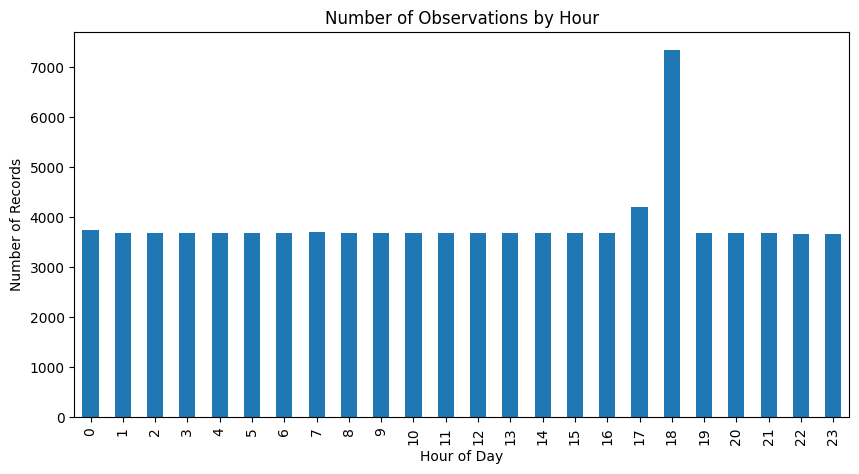

In [30]:
plt.figure(figsize=(10, 5))

hour_counts.plot(kind="bar")

plt.title("Number of Observations by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Records")

plt.show()

Investigate remarks

In [31]:
df_clean["remarks"].value_counts(dropna=False).head(20)

remarks
NaN             86257
Day_Peak         3293
Evening_Peak     3100
Name: count, dtype: int64

Remarks among duplicate timestamps

In [32]:
duplicate_rows = df_clean[
    df_clean["datetime"].duplicated(keep=False)
]

duplicate_rows["remarks"].value_counts(dropna=False)

remarks
NaN             777
Evening_Peak     19
Day_Peak         17
Name: count, dtype: int64

In [33]:
print("Completely identical duplicate rows:", exact_duplicates)

Completely identical duplicate rows: 160


In [34]:
timestamp_counts.head(20)

datetime
2015-12-21 07:00:00    9
2016-12-02 16:00:00    7
2016-03-20 00:00:00    5
2016-12-28 06:00:00    5
2016-12-17 06:00:00    4
2016-05-07 21:00:00    4
2016-09-30 09:00:00    4
2016-09-23 20:00:00    4
2016-06-24 21:00:00    4
2015-09-17 07:00:00    4
2015-08-08 02:00:00    4
2015-04-30 00:00:00    3
2015-08-09 09:00:00    3
2015-08-09 10:00:00    3
2015-12-31 22:00:00    3
2015-06-15 00:00:00    3
2016-03-25 07:00:00    3
2015-06-02 00:00:00    3
2016-06-18 18:30:00    3
2015-08-05 12:00:00    3
Name: count, dtype: int64

In [35]:
minute_counts

datetime
0     88469
30     4181
Name: count, dtype: int64

In [36]:
missing = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (
        df_clean.isnull().mean() * 100
    ).round(2)
})

missing[missing["Missing_Count"] > 0].sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
nepal,87299,94.22
remarks,86257,93.10
india_adani,85312,92.08
wind,73974,79.84
solar,22133,23.89


Remove only exact duplicates

In [37]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Rows after removing exact duplicates:", len(df_clean))

Rows after removing exact duplicates: 92490


Recheck timestamp duplicates

In [38]:
print(
    "Remaining duplicate timestamps:",
    df_clean["datetime"].duplicated().sum()
)

print(
    "Rows involved in duplicate timestamps:",
    df_clean["datetime"].duplicated(keep=False).sum()
)

print(
    "Unique timestamps with conflicts:",
    df_clean.loc[
        df_clean["datetime"].duplicated(keep=False),
        "datetime"
    ].nunique()
)

Remaining duplicate timestamps: 272
Rows involved in duplicate timestamps: 534
Unique timestamps with conflicts: 262


Separate the half-hour observations

In [39]:
df_hourly = df_clean[
    df_clean["datetime"].dt.minute == 0
].copy()

df_half_hour = df_clean[
    df_clean["datetime"].dt.minute == 30
].copy()

print("Hourly records:", len(df_hourly))
print("Half-hour records:", len(df_half_hour))

Hourly records: 88314
Half-hour records: 4176


Check duplicate timestamps in hourly data

In [40]:
print(
    "Duplicate hourly timestamps:",
    df_hourly["datetime"].duplicated().sum()
)

Duplicate hourly timestamps: 268


In [41]:
hourly_duplicates = df_hourly[
    df_hourly["datetime"].duplicated(keep=False)
].sort_values("datetime")

hourly_duplicates.head(30)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
76,2015-04-22 21:00:00,5811.0,5811,0,4158,1021,162,30,NaN,NaN,440,0,NaN,NaN,NaN
77,2015-04-22 21:00:00,5368.0,5368,0,4184,552,160,30,NaN,NaN,442,0,NaN,NaN,NaN
79,2015-04-23 00:00:00,5726.0,5726,0,4199,790,158,46,NaN,NaN,433,0,NaN,NaN,NaN
80,2015-04-23 00:00:00,3976.0,3976,0,3116,230,158,30,NaN,NaN,442,0,NaN,NaN,NaN
158,2015-04-27 00:00:00,5236.0,5236,0,4417,159,162,46,NaN,NaN,452,0,NaN,NaN,NaN
159,2015-04-27 00:00:00,4800.0,4800,0,3954,117,166,46,NaN,NaN,458,0,NaN,NaN,NaN
160,2015-04-27 00:00:00,5459.0,5459,0,4457,363,148,45,NaN,NaN,458,0,NaN,NaN,NaN
238,2015-04-30 00:00:00,5809.0,5809,0,4901,257,154,46,NaN,NaN,451,0,NaN,NaN,NaN
239,2015-04-30 00:00:00,6065.0,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN,NaN
240,2015-04-30 00:00:00,6889.0,6889,0,4698,1540,157,42,NaN,NaN,452,0,NaN,NaN,Evening_Peak


Resolve conflicting hourly timestamps

In [42]:
numeric_columns = [
    col for col in df_hourly.columns
    if col not in ["datetime", "remarks"]
]

In [43]:
aggregation_rules = {
    col: "median"
    for col in numeric_columns
}

# For load shedding, retain an event if one was reported.
aggregation_rules["load_shedding"] = "max"

In [44]:
aggregation_rules["remarks"] = lambda x: (
    " | ".join(sorted(set(x.dropna().astype(str))))
    if x.notna().any()
    else np.nan
)

In [45]:
df_hourly = (
    df_hourly
    .groupby("datetime", as_index=False)
    .agg(aggregation_rules)
    .sort_values("datetime")
    .reset_index(drop=True)
)

In [46]:
print("Hourly dataset shape:", df_hourly.shape)

print(
    "Remaining duplicate timestamps:",
    df_hourly["datetime"].duplicated().sum()
)

Hourly dataset shape: (88046, 15)
Remaining duplicate timestamps: 0


In [47]:
print(df_hourly.shape)
print(df_hourly["datetime"].duplicated().sum())

(88046, 15)
0


check negative values

In [48]:
numeric_cols = df_hourly.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    negative_count = (df_hourly[col] < 0).sum()
    
    if negative_count > 0:
        print(col, ":", negative_count)

Examine important percentiles

In [49]:
key_columns = [
    "generation_mw",
    "demand_mw",
    "load_shedding",
    "gas",
    "liquid_fuel",
    "coal",
    "hydro",
    "solar",
    "wind",
    "india_bheramara_hvdc",
    "india_tripura",
    "india_adani",
    "nepal"
]

percentile_summary = df_hourly[key_columns].quantile(
    [0, 0.001, 0.01, 0.50, 0.99, 0.999, 1]
).T

percentile_summary

,0.000,0.001,0.010,0.500,0.990,0.999,1.000
generation_mw,73.0,3412.1485,4167.00,8371.0,14430.10,15623.955,64526500.0
demand_mw,6.0,3259.6300,4145.00,8381.5,15087.70,16230.000,121000.0
load_shedding,0.0,0.0000,0.00,0.0,1533.00,2589.820,65359.0
gas,0.0,1538.2600,3302.45,5025.0,7100.00,7686.000,74818.0
liquid_fuel,0.0,0.0000,0.00,1483.0,4979.00,6130.685,29222897.0
coal,0.0,0.0000,0.00,417.0,4553.55,5350.955,31687.0
hydro,0.0,0.0000,0.00,78.0,238.00,313.955,5623.0
solar,0.0,0.0000,0.00,0.0,502.00,633.472,2998.0
wind,0.0,0.0000,0.00,4.0,56.00,64.091,922.0
india_bheramara_hvdc,0.0,0.0000,128.00,707.0,953.00,961.000,76292.0


find the highest demand values

In [50]:
df_hourly[
    [
        "datetime",
        "demand_mw",
        "generation_mw",
        "load_shedding",
        "remarks"
    ]
].sort_values(
    "demand_mw",
    ascending=False
).head(20)

,datetime,demand_mw,generation_mw,load_shedding,remarks
77803,2024-04-16 07:00:00,121000.0,11701.0,381,NaN
73294,2023-10-11 03:00:00,117000.0,11468.0,222,NaN
79672,2024-07-03 05:00:00,111140.0,11080.0,57,NaN
19927,2017-08-26 15:00:00,80689.0,8068.0,65359,NaN
17528,2017-05-17 12:00:00,74223.0,7423.0,60120,NaN
31260,2018-12-18 08:00:00,55639.0,5563.9,45068,NaN
73134,2023-10-04 09:00:00,20587.0,10587.0,0,NaN
78128,2024-04-29 20:00:00,17200.0,15595.0,1533,Evening_Peak
78104,2024-04-28 20:00:00,17150.0,15816.0,1274,Evening_Peak
78129,2024-04-29 21:00:00,17100.0,15527.0,1502,NaN


Find highest generation values

In [51]:
df_hourly[
    [
        "datetime",
        "generation_mw",
        "demand_mw",
        "load_shedding",
        "remarks"
    ]
].sort_values(
    "generation_mw",
    ascending=False
).head(20)

,datetime,generation_mw,demand_mw,load_shedding,remarks
66859,2023-01-15 04:00:00,64526500.0,6452.0,0,NaN
87141,2025-05-10 20:00:00,16603.0,17000.0,379,Evening_Peak
78152,2024-04-30 20:00:00,16477.0,17000.0,499,Evening_Peak
87143,2025-05-10 22:00:00,16373.0,16750.0,360,NaN
87142,2025-05-10 21:00:00,16368.0,16700.0,317,NaN
87144,2025-05-10 23:00:00,16363.0,16690.0,312,NaN
78151,2024-04-30 19:00:00,16245.0,16850.0,578,NaN
77960,2024-04-22 20:00:00,16233.0,16700.0,446,Evening_Peak
86756,2025-04-24 19:00:00,16221.0,16350.0,123,NaN
87140,2025-05-10 19:00:00,16201.0,16850.0,620,NaN


Check generation-source extremes

In [52]:
for col in [
    "gas",
    "liquid_fuel",
    "coal",
    "hydro",
    "solar",
    "wind",
    "india_bheramara_hvdc",
    "india_tripura",
    "india_adani",
    "nepal"
]:
    
    print("\n", "=" * 40)
    print(col.upper())
    
    display(
        df_hourly[
            ["datetime", col]
        ].sort_values(
            col,
            ascending=False
        ).head(10)
    )


GAS


,datetime,gas
21142,2017-10-16 07:00:00,74818.0
35624,2019-06-19 08:00:00,68763.0
63475,2022-08-27 01:00:00,66662.0
71530,2023-07-29 10:00:00,61501.0
72383,2023-09-03 01:00:00,59991.0
40040,2019-12-22 22:00:00,59004.0
27386,2018-07-09 03:00:00,54112.0
22306,2017-12-04 20:00:00,49121.0
32212,2019-01-27 03:00:00,49018.0
67599,2023-02-15 02:00:00,47612.0



LIQUID_FUEL


,datetime,liquid_fuel
59291,2022-03-05 08:00:00,29222897.0
16530,2017-04-05 01:00:00,893165.0
15636,2017-02-25 23:00:00,698113.0
9623,2016-05-28 19:00:00,42435.0
3467,2015-09-14 10:00:00,41512.0
69012,2023-04-15 04:00:00,34146.0
63238,2022-08-17 04:00:00,33332.0
61910,2022-06-22 15:00:00,32222.0
71103,2023-07-11 14:00:00,31423.0
54639,2021-08-23 04:00:00,29834.0



COAL


...

,datetime,india_tripura
46912,2020-10-04 18:00:00,1565.0
62313,2022-07-09 12:00:00,1234.0
71785,2023-08-09 02:00:00,1132.0
45772,2020-08-18 06:00:00,1000.0
61178,2022-05-23 03:00:00,1000.0
56468,2021-11-07 13:00:00,1000.0
60925,2022-05-12 14:00:00,1000.0
33484,2019-03-21 18:00:00,955.0
34637,2019-05-09 02:00:00,942.0
69601,2023-05-09 18:00:00,929.0



INDIA_ADANI


,datetime,india_adani
86793,2025-04-26 08:00:00,12665.0
86926,2025-05-01 21:00:00,11241.0
84714,2025-01-29 15:00:00,9709.0
86855,2025-04-28 22:00:00,1578.0
86856,2025-04-28 23:00:00,1576.0
86854,2025-04-28 21:00:00,1575.0
86851,2025-04-28 18:00:00,1573.0
86078,2025-03-27 13:00:00,1571.0
86077,2025-03-27 12:00:00,1570.0
86852,2025-04-28 19:00:00,1569.0



NEPAL


,datetime,nepal
82925,2024-11-15 23:00:00,38.0
88030,2025-06-16 21:00:00,38.0
88029,2025-06-16 20:00:00,38.0
82922,2024-11-15 20:00:00,38.0
88045,2025-06-17 12:00:00,38.0
82896,2024-11-14 18:00:00,38.0
82914,2024-11-15 12:00:00,38.0
82915,2024-11-15 13:00:00,38.0
82916,2024-11-15 14:00:00,38.0
82917,2024-11-15 15:00:00,38.0


Visualize demand distribution

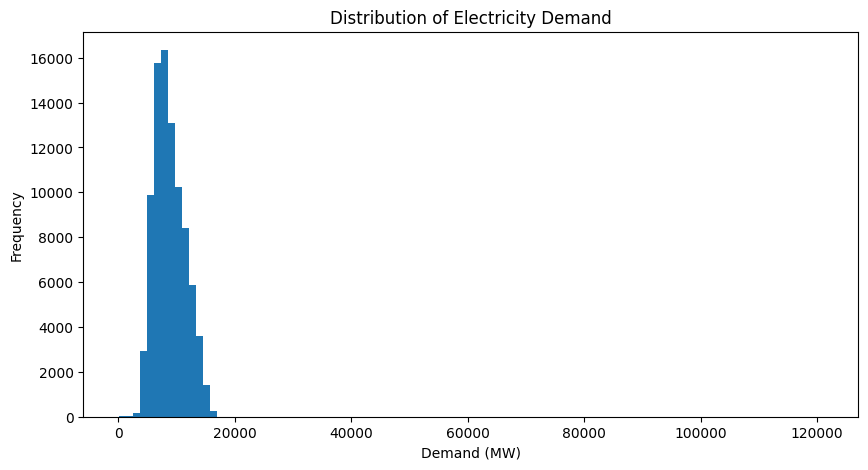

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_hourly["demand_mw"],
    bins=100
)

plt.title("Distribution of Electricity Demand")
plt.xlabel("Demand (MW)")
plt.ylabel("Frequency")

plt.show()

Boxplot demand

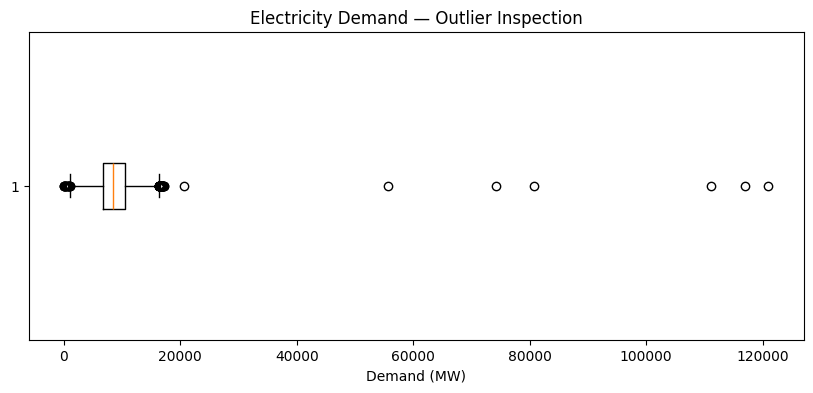

In [54]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df_hourly["demand_mw"].dropna(),
    vert=False
)

plt.title("Electricity Demand — Outlier Inspection")
plt.xlabel("Demand (MW)")

plt.show()

Compare demand and generation extremes

In [55]:
print("Demand")
print(df_hourly["demand_mw"].describe())

print("\nGeneration")
print(df_hourly["generation_mw"].describe())

Demand
count     88046.000000
mean       8776.336426
std        2709.863352
min           6.000000
25%        6769.000000
50%        8381.500000
75%       10591.000000
max      121000.000000
Name: demand_mw, dtype: float64

Generation
count    8.804600e+04
mean     9.423980e+03
std      2.174468e+05
min      7.300000e+01
25%      6.771000e+03
50%      8.371000e+03
75%      1.051398e+04
max      6.452650e+07
Name: generation_mw, dtype: float64


In [56]:
print(
    "Demand 99.9 percentile:",
    df_hourly["demand_mw"].quantile(0.999)
)

print(
    "Demand maximum:",
    df_hourly["demand_mw"].max()
)

print(
    "\nGeneration 99.9 percentile:",
    df_hourly["generation_mw"].quantile(0.999)
)

print(
    "Generation maximum:",
    df_hourly["generation_mw"].max()
)

Demand 99.9 percentile: 16230.0
Demand maximum: 121000.0

Generation 99.9 percentile: 15623.955000000016
Generation maximum: 64526500.0


In [57]:
df_hourly["demand_change"] = (
    df_hourly["demand_mw"]
    .diff()
    .abs()
)

df_hourly[
    [
        "datetime",
        "demand_mw",
        "demand_change"
    ]
].sort_values(
    "demand_change",
    ascending=False
).head(20)

,datetime,demand_mw,demand_change
77803,2024-04-16 07:00:00,121000.0,109050.0
77804,2024-04-16 08:00:00,12450.0,108550.0
73295,2023-10-11 04:00:00,11440.0,105560.0
73294,2023-10-11 03:00:00,117000.0,105000.0
79673,2024-07-03 06:00:00,11200.0,99940.0
79672,2024-07-03 05:00:00,111140.0,99620.0
19928,2017-08-26 16:00:00,7976.0,72713.0
19927,2017-08-26 15:00:00,80689.0,72609.0
17528,2017-05-17 12:00:00,74223.0,66870.0
17529,2017-05-17 13:00:00,7405.0,66818.0


In [58]:
df_hourly["generation_change"] = (
    df_hourly["generation_mw"]
    .diff()
    .abs()
)

df_hourly[
    [
        "datetime",
        "generation_mw",
        "generation_change"
    ]
].sort_values(
    "generation_change",
    ascending=False
).head(20)

,datetime,generation_mw,generation_change
66859,2023-01-15 04:00:00,64526500.0,64520025.0
66860,2023-01-15 05:00:00,6653.0,64519847.0
61980,2022-06-25 13:00:00,1816.0,10261.0
61981,2022-06-25 14:00:00,11844.0,10028.0
76781,2024-03-04 15:00:00,1026.0,9413.0
76782,2024-03-04 16:00:00,10142.0,9116.0
21161,2017-10-17 02:00:00,9841.0,8958.0
47283,2020-10-20 08:00:00,9326.0,8419.0
21160,2017-10-17 01:00:00,883.0,8151.0
47282,2020-10-20 07:00:00,907.0,8068.0


In [59]:
df_hourly["local_median_demand"] = (
    df_hourly["demand_mw"]
    .rolling(window=5, center=True, min_periods=3)
    .median()
)

In [60]:
df_hourly["demand_ratio"] = (
    df_hourly["demand_mw"]
    / df_hourly["local_median_demand"]
)

print("demand_ratio created")

demand_ratio created


In [61]:
df_hourly["demand_anomaly"] = (
    (df_hourly["demand_ratio"] > 1.5) |
    (df_hourly["demand_ratio"] < 0.5)
)

print("Demand anomalies detected:", df_hourly["demand_anomaly"].sum())
print(
    "Percentage flagged:",
    round(df_hourly["demand_anomaly"].mean() * 100, 4),
    "%"
)

Demand anomalies detected: 54
Percentage flagged: 0.0613 %


calculate the demand ratio

In [62]:
df_hourly["demand_ratio"] = (
    df_hourly["demand_mw"]
    / df_hourly["local_median_demand"]
)

df_hourly[
    [
        "datetime",
        "demand_mw",
        "local_median_demand",
        "demand_ratio"
    ]
].sort_values(
    "demand_ratio",
    ascending=False
).head(20)

,datetime,demand_mw,local_median_demand,demand_ratio
17528,2017-05-17 12:00:00,74223.0,7405.0,10.023363
19927,2017-08-26 15:00:00,80689.0,8080.0,9.986262
73294,2023-10-11 03:00:00,117000.0,12000.0,9.750000
31260,2018-12-18 08:00:00,55639.0,5723.0,9.721999
77803,2024-04-16 07:00:00,121000.0,12450.0,9.718876
79672,2024-07-03 05:00:00,111140.0,11520.0,9.647569
73134,2023-10-04 09:00:00,20587.0,10716.0,1.921146
32524,2019-02-09 05:00:00,7576.0,5119.0,1.479977
47689,2020-11-06 06:00:00,8506.0,5984.0,1.421457
779,2015-05-25 03:00:00,7076.0,5353.0,1.321876


In [63]:
demand_anomalies = df_hourly.loc[
    df_hourly["demand_anomaly"],
    [
        "datetime",
        "demand_mw",
        "local_median_demand",
        "demand_ratio",
        "generation_mw",
        "load_shedding"
    ]
].copy()

demand_anomalies

,datetime,demand_mw,local_median_demand,demand_ratio,generation_mw,load_shedding
7235,2016-02-18 23:00:00,1419.0,6146.0,0.230882,6014.0,0
12269,2016-09-16 06:00:00,746.0,5550.0,0.134414,746.0,0
14283,2016-12-09 20:00:00,80.0,5926.0,0.013500,80.0,0
17528,2017-05-17 12:00:00,74223.0,7405.0,10.023363,7423.0,60120
19927,2017-08-26 15:00:00,80689.0,8080.0,9.986262,8068.0,65359
21144,2017-10-16 09:00:00,73.0,7580.0,0.009631,73.0,0
22991,2018-01-04 20:00:00,611.0,6561.0,0.093126,611.0,0
23205,2018-01-14 11:00:00,6.0,6071.0,0.000988,6021.6,0
23289,2018-01-17 23:00:00,236.0,5412.0,0.043607,236.0,0
31260,2018-12-18 08:00:00,55639.0,5723.0,9.721999,5563.9,45068


preserve the original demand

In [64]:
df_hourly["demand_mw_original"] = df_hourly["demand_mw"]

create a cleaned copy

In [65]:
df_hourly["demand_mw_clean"] = df_hourly["demand_mw"].astype(float)

df_hourly.loc[
    df_hourly["demand_anomaly"],
    "demand_mw_clean"
] = np.nan

interpolate using time

In [66]:
df_hourly = df_hourly.sort_values("datetime")

df_hourly = df_hourly.set_index("datetime")

df_hourly["demand_mw_clean"] = (
    df_hourly["demand_mw_clean"]
    .interpolate(method="time")
)

df_hourly = df_hourly.reset_index()

Verify the cleaned demand

In [67]:
print("Original demand:")
print(df_hourly["demand_mw_original"].describe())

print("\nCleaned demand:")
print(df_hourly["demand_mw_clean"].describe())

Original demand:
count     88046.000000
mean       8776.336426
std        2709.863352
min           6.000000
25%        6769.000000
50%        8381.500000
75%       10591.000000
max      121000.000000
Name: demand_mw_original, dtype: float64

Cleaned demand:
count    88046.000000
mean      8775.842844
std       2605.917056
min       1759.000000
25%       6772.000000
50%       8385.000000
75%      10594.000000
max      17200.000000
Name: demand_mw_clean, dtype: float64


In [68]:
df_hourly.loc[
    df_hourly["demand_anomaly"],
    [
        "datetime",
        "demand_mw_original",
        "demand_mw_clean",
        "local_median_demand",
        "generation_mw"
    ]
].head(20)

,datetime,demand_mw_original,demand_mw_clean,local_median_demand,generation_mw
7235,2016-02-18 23:00:00,1419.0,6223.000000,6146.0,6014.0
12269,2016-09-16 06:00:00,746.0,5612.500000,5550.0,746.0
14283,2016-12-09 20:00:00,80.0,6275.500000,5926.0,80.0
17528,2017-05-17 12:00:00,74223.0,7379.000000,7405.0,7423.0
19927,2017-08-26 15:00:00,80689.0,8028.000000,8080.0,8068.0
21144,2017-10-16 09:00:00,73.0,7710.000000,7580.0,73.0
22991,2018-01-04 20:00:00,611.0,7084.500000,6561.0,611.0
23205,2018-01-14 11:00:00,6.0,6092.000000,6071.0,6021.6
23289,2018-01-17 23:00:00,236.0,5966.500000,5412.0,236.0
31260,2018-12-18 08:00:00,55639.0,5316.500000,5723.0,5563.9


saving checkpoint

In [69]:
df_hourly.to_csv(
    "PGCB_hourly_preprocessed_stage1.csv",
    index=False
)

print("Stage 1 dataset saved successfully.")

Stage 1 dataset saved successfully.


In [70]:
df_hourly["local_median_generation"] = (
    df_hourly["generation_mw"]
    .rolling(
        window=5,
        center=True,
        min_periods=3
    )
    .median()
)

df_hourly["generation_ratio"] = (
    df_hourly["generation_mw"]
    / df_hourly["local_median_generation"]
)

df_hourly["generation_anomaly"] = (
    (df_hourly["generation_ratio"] > 1.5) |
    (df_hourly["generation_ratio"] < 0.5)
)

print(
    "Generation anomalies detected:",
    df_hourly["generation_anomaly"].sum()
)

print(
    "Percentage flagged:",
    round(
        df_hourly["generation_anomaly"].mean() * 100,
        4
    ),
    "%"
)

Generation anomalies detected: 11
Percentage flagged: 0.0125 %


In [71]:
generation_anomalies = df_hourly.loc[
    df_hourly["generation_anomaly"],
    [
        "datetime",
        "generation_mw",
        "local_median_generation",
        "generation_ratio",
        "demand_mw_clean",
        "load_shedding"
    ]
].copy()

generation_anomalies

,datetime,generation_mw,local_median_generation,generation_ratio,demand_mw_clean,load_shedding
12269,2016-09-16 06:00:00,746.0,5550.0,0.134414,5612.5,0
14283,2016-12-09 20:00:00,80.0,5926.0,0.013500,6275.5,0
21144,2017-10-16 09:00:00,73.0,7579.6,0.009631,7710.0,0
21160,2017-10-17 01:00:00,883.0,9034.0,0.097742,8830.0,7152
22991,2018-01-04 20:00:00,611.0,6561.0,0.093126,7084.5,0
23289,2018-01-17 23:00:00,236.0,5412.0,0.043607,5966.5,0
47282,2020-10-20 07:00:00,907.0,9326.0,0.097255,9072.0,7348
48836,2020-12-24 02:00:00,571.0,5593.0,0.102092,5711.0,4626
61980,2022-06-25 13:00:00,1816.0,11756.0,0.154474,11816.0,9000
66859,2023-01-15 04:00:00,64526500.0,6709.0,9617.901327,6452.0,0


In [72]:
df_hourly["generation_mw_original"] = df_hourly["generation_mw"]

In [73]:
df_hourly["generation_mw_clean"] = (
    df_hourly["generation_mw"].astype(float)
)

df_hourly.loc[
    df_hourly["generation_anomaly"],
    "generation_mw_clean"
] = np.nan

In [74]:
df_hourly = df_hourly.sort_values("datetime")

df_hourly = df_hourly.set_index("datetime")

df_hourly["generation_mw_clean"] = (
    df_hourly["generation_mw_clean"]
    .interpolate(method="time")
)

df_hourly = df_hourly.reset_index()

In [75]:
print("Original generation:")
print(df_hourly["generation_mw_original"].describe())

print("\nCleaned generation:")
print(df_hourly["generation_mw_clean"].describe())

Original generation:
count    8.804600e+04
mean     9.423980e+03
std      2.174468e+05
min      7.300000e+01
25%      6.771000e+03
50%      8.371000e+03
75%      1.051398e+04
max      6.452650e+07
Name: generation_mw_original, dtype: float64

Cleaned generation:
count    88046.000000
mean      8692.003109
std       2479.559224
min       1759.000000
25%       6771.025000
50%       8371.700000
75%      10513.975000
max      16603.000000
Name: generation_mw_clean, dtype: float64


In [76]:
df_hourly.loc[
    df_hourly["generation_anomaly"],
    [
        "datetime",
        "generation_mw_original",
        "generation_mw_clean",
        "local_median_generation",
        "demand_mw_clean"
    ]
]

,datetime,generation_mw_original,generation_mw_clean,local_median_generation,demand_mw_clean
12269,2016-09-16 06:00:00,746.0,5612.50,5550.0,5612.5
14283,2016-12-09 20:00:00,80.0,6275.50,5926.0,6275.5
21144,2017-10-16 09:00:00,73.0,7709.65,7579.6,7710.0
21160,2017-10-17 01:00:00,883.0,9437.50,9034.0,8830.0
22991,2018-01-04 20:00:00,611.0,7084.50,6561.0,7084.5
23289,2018-01-17 23:00:00,236.0,5966.50,5412.0,5966.5
47282,2020-10-20 07:00:00,907.0,9150.50,9326.0,9072.0
48836,2020-12-24 02:00:00,571.0,5775.50,5593.0,5711.0
61980,2022-06-25 13:00:00,1816.0,11960.50,11756.0,11816.0
66859,2023-01-15 04:00:00,64526500.0,6564.00,6709.0,6452.0


save checkpoint

In [77]:
df_hourly.to_csv(
    "PGCB_hourly_preprocessed_stage2.csv",
    index=False
)

print("Stage 2 dataset saved successfully.")

Stage 2 dataset saved successfully.


Inspect load-shedding distribution

In [78]:
print(df_hourly["load_shedding"].describe())

print("\nRows with no load shedding:",
      (df_hourly["load_shedding"] == 0).sum())

print("Rows with load shedding:",
      (df_hourly["load_shedding"] > 0).sum())

print("Negative values:",
      (df_hourly["load_shedding"] < 0).sum())

count    88046.000000
mean        82.509132
std        450.728457
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      65359.000000
Name: load_shedding, dtype: float64

Rows with no load shedding: 73908
Rows with load shedding: 14138
Negative values: 0


In [79]:
df_hourly[
    [
        "datetime",
        "load_shedding",
        "demand_mw_clean",
        "generation_mw_clean"
    ]
].sort_values(
    "load_shedding",
    ascending=False
).head(30)

,datetime,load_shedding,demand_mw_clean,generation_mw_clean
19927,2017-08-26 15:00:00,65359,8028.0,8068.0
17528,2017-05-17 12:00:00,60120,7379.0,7423.0
31260,2018-12-18 08:00:00,45068,5316.5,5563.9
80550,2024-08-08 23:00:00,13800,13600.0,13650.0
80203,2024-07-25 10:00:00,13500,13440.0,13043.0
64458,2022-10-07 01:00:00,11672,11672.0,9833.0
64665,2022-10-15 16:00:00,9098,11211.0,10020.0
61980,2022-06-25 13:00:00,9000,11816.0,11960.5
64399,2022-10-04 14:00:00,7852,11350.0,2830.0
47282,2020-10-20 07:00:00,7348,9072.0,9150.5


Flag physically suspicious values

In [80]:
df_hourly["load_shedding_suspicious"] = (
    df_hourly["load_shedding"] >
    df_hourly["demand_mw_clean"]
)

print(
    "Load-shedding values greater than demand:",
    df_hourly["load_shedding_suspicious"].sum()
)

Load-shedding values greater than demand: 5


In [81]:
df_hourly.loc[
    df_hourly["load_shedding_suspicious"],
    [
        "datetime",
        "load_shedding",
        "demand_mw_clean",
        "generation_mw_clean"
    ]
]

,datetime,load_shedding,demand_mw_clean,generation_mw_clean
17528,2017-05-17 12:00:00,60120,7379.0,7423.0
19927,2017-08-26 15:00:00,65359,8028.0,8068.0
31260,2018-12-18 08:00:00,45068,5316.5,5563.9
80203,2024-07-25 10:00:00,13500,13440.0,13043.0
80550,2024-08-08 23:00:00,13800,13600.0,13650.0


load_shedding_event

In [82]:
df_hourly["load_shedding_event"] = (
    df_hourly["load_shedding"] > 0
).astype(int)

print(df_hourly["load_shedding_event"].value_counts())

print("\nPercentage:")
print(
    df_hourly["load_shedding_event"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

load_shedding_event
0    73908
1    14138
Name: count, dtype: int64

Percentage:
load_shedding_event
0    83.94
1    16.06
Name: proportion, dtype: float64


save check point


In [83]:
df_hourly.to_csv(
    "PGCB_hourly_preprocessed_stage3.csv",
    index=False
)

print("Stage 3 dataset saved successfully.")

Stage 3 dataset saved successfully.


Then inspect generation-source columns

In [84]:
source_columns = [
    "gas",
    "liquid_fuel",
    "coal",
    "hydro",
    "solar",
    "wind",
    "india_bheramara_hvdc",
    "india_tripura",
    "india_adani",
    "nepal"
]

source_summary = pd.DataFrame({
    "count": df_hourly[source_columns].count(),
    "missing": df_hourly[source_columns].isnull().sum(),
    "missing_%": (
        df_hourly[source_columns].isnull().mean() * 100
    ).round(2),
    "min": df_hourly[source_columns].min(),
    "median": df_hourly[source_columns].median(),
    "99%": df_hourly[source_columns].quantile(0.99),
    "99.9%": df_hourly[source_columns].quantile(0.999),
    "max": df_hourly[source_columns].max()
})

source_summary

,count,missing,missing_%,min,median,99%,99.9%,max
gas,88046,0,0.00,0.0,5025.0,7100.00,7686.000,74818.0
liquid_fuel,88046,0,0.00,0.0,1483.0,4979.00,6130.685,29222897.0
coal,88046,0,0.00,0.0,417.0,4553.55,5350.955,31687.0
hydro,88046,0,0.00,0.0,78.0,238.00,313.955,5623.0
solar,67529,20517,23.30,0.0,0.0,502.00,633.472,2998.0
wind,17910,70136,79.66,0.0,4.0,56.00,64.091,922.0
india_bheramara_hvdc,88046,0,0.00,0.0,707.0,953.00,961.000,76292.0
india_tripura,88046,0,0.00,0.0,96.0,174.00,190.000,1565.0
india_adani,7039,81007,92.01,0.0,821.0,1510.00,1570.962,12665.0
nepal,5133,82913,94.17,0.0,0.0,38.00,38.000,38.0


flag only extreme HIGH source anomalies

In [85]:
source_columns = [
    "gas",
    "liquid_fuel",
    "coal",
    "hydro",
    "solar",
    "wind",
    "india_bheramara_hvdc",
    "india_tripura",
    "india_adani",
    "nepal"
]

source_anomaly_summary = []

for col in source_columns:
    
    q999 = df_hourly[col].quantile(0.999)
    threshold = q999 * 3
    
    anomaly_col = f"{col}_anomaly"
    
    df_hourly[anomaly_col] = (
        df_hourly[col] > threshold
    )
    
    source_anomaly_summary.append({
        "source": col,
        "99.9_percentile": q999,
        "threshold": threshold,
        "anomalies": df_hourly[anomaly_col].sum()
    })

source_anomaly_summary = pd.DataFrame(source_anomaly_summary)

source_anomaly_summary

,source,99.9_percentile,threshold,anomalies
0,gas,7686.000,23058.000,19
1,liquid_fuel,6130.685,18392.055,18
2,coal,5350.955,16052.865,3
3,hydro,313.955,941.865,37
4,solar,633.472,1900.416,3
5,wind,64.091,192.273,7
6,india_bheramara_hvdc,961.000,2883.000,15
7,india_tripura,190.000,570.000,27
8,india_adani,1570.962,4712.886,3
9,nepal,38.000,114.000,0


inspect the flagged records

In [86]:
for col in source_columns:
    
    anomaly_col = f"{col}_anomaly"
    
    flagged = df_hourly.loc[
        df_hourly[anomaly_col],
        [
            "datetime",
            col,
            "generation_mw_clean",
            "demand_mw_clean"
        ]
    ]
    
    if len(flagged) > 0:
        print("\n", "=" * 50)
        print(col.upper())
        print("Flagged rows:", len(flagged))
        display(flagged)


GAS
Flagged rows: 19


,datetime,gas,generation_mw_clean,demand_mw_clean
1155,2015-06-09 21:00:00,44442.0,7704.0,7704.0
3864,2015-10-01 02:00:00,44158.0,6614.0,6614.0
6654,2016-01-25 17:00:00,33861.0,6581.0,6581.0
8002,2016-03-22 02:00:00,40179.0,6271.0,6271.0
10547,2016-07-06 08:00:00,36136.0,4358.0,4358.0
21142,2017-10-16 07:00:00,74818.0,7196.8,7197.0
22306,2017-12-04 20:00:00,49121.0,7359.0,7359.0
23578,2018-01-30 01:00:00,42225.0,5165.0,5165.0
27386,2018-07-09 03:00:00,54112.0,9161.0,9161.0
32212,2019-01-27 03:00:00,49018.0,5644.0,5644.0



LIQUID_FUEL
Flagged rows: 18


,datetime,liquid_fuel,generation_mw_clean,demand_mw_clean
3467,2015-09-14 10:00:00,41512.0,6758.0,6758.0
9623,2016-05-28 19:00:00,42435.0,7873.0,7873.0
15636,2017-02-25 23:00:00,698113.0,6025.0,6025.0
16530,2017-04-05 01:00:00,893165.0,6308.0,6308.0
17865,2017-06-01 02:00:00,18902.0,7945.0,7945.0
26667,2018-06-08 18:00:00,29223.0,9464.0,9464.0
36062,2019-07-07 14:00:00,24958.0,9545.1,9545.0
53963,2021-07-26 00:00:00,18880.0,10667.0,10667.0
54639,2021-08-23 04:00:00,29834.0,11319.0,11319.0
58837,2022-02-14 10:00:00,27229.0,8523.0,8523.0



COAL
Flagged rows: 3


...

,datetime,india_bheramara_hvdc,generation_mw_clean,demand_mw_clean
30,2015-04-20 13:00:00,6069.0,6069.0,6069.0
1115,2015-06-08 05:00:00,6417.0,6417.0,6417.0
2041,2015-07-16 21:00:00,4444.0,6978.0,6978.0
3554,2015-09-18 02:00:00,7425.0,7425.0,7425.0
13707,2016-11-15 20:00:00,5014.0,7139.0,7139.0
16728,2017-04-13 08:00:00,4998.0,7414.0,7414.0
17406,2017-05-12 09:00:00,4950.0,5722.0,5722.0
24298,2018-03-01 11:00:00,4591.0,7467.0,7467.0
28789,2018-09-05 20:00:00,4882.0,10726.0,10726.0
33117,2019-03-05 22:00:00,76292.0,6923.0,6923.0



INDIA_TRIPURA
Flagged rows: 27


,datetime,india_tripura,generation_mw_clean,demand_mw_clean
33484,2019-03-21 18:00:00,955.0,10451.0,10451.0
34637,2019-05-09 02:00:00,942.0,11042.0,11042.0
36346,2019-07-19 10:00:00,904.0,8195.0,8195.0
36857,2019-08-09 17:00:00,750.0,7924.5,7925.0
38293,2019-10-08 23:00:00,915.0,9257.0,9257.0
40417,2020-01-07 16:00:00,606.0,6596.1,6596.0
43763,2020-05-26 11:00:00,869.0,5863.0,5863.0
45772,2020-08-18 06:00:00,1000.0,8492.7,8493.0
46912,2020-10-04 18:00:00,1565.0,12317.0,12317.0
49916,2021-02-07 03:00:00,600.0,5852.0,5852.0



INDIA_ADANI
Flagged rows: 3


,datetime,india_adani,generation_mw_clean,demand_mw_clean
84714,2025-01-29 15:00:00,9709.0,9709.0,9780.0
86793,2025-04-26 08:00:00,12665.0,12665.0,12850.0
86926,2025-05-01 21:00:00,11241.0,11241.0,11241.0


In [87]:
source_anomaly_summary

,source,99.9_percentile,threshold,anomalies
0,gas,7686.000,23058.000,19
1,liquid_fuel,6130.685,18392.055,18
2,coal,5350.955,16052.865,3
3,hydro,313.955,941.865,37
4,solar,633.472,1900.416,3
5,wind,64.091,192.273,7
6,india_bheramara_hvdc,961.000,2883.000,15
7,india_tripura,190.000,570.000,27
8,india_adani,1570.962,4712.886,3
9,nepal,38.000,114.000,0


inspect candidates with neighboring values

In [88]:
source_anomaly_rows = []

for col in source_columns:

    anomaly_col = f"{col}_anomaly"

    # Local 5-hour median
    local_median = (
        df_hourly[col]
        .rolling(window=5, center=True, min_periods=3)
        .median()
    )

    flagged_indices = df_hourly.index[df_hourly[anomaly_col]]

    for idx in flagged_indices:

        current_value = df_hourly.loc[idx, col]
        median_value = local_median.loc[idx]

        source_anomaly_rows.append({
            "source": col,
            "datetime": df_hourly.loc[idx, "datetime"],
            "previous_value": (
                df_hourly.loc[idx - 1, col]
                if idx > 0 else np.nan
            ),
            "current_value": current_value,
            "next_value": (
                df_hourly.loc[idx + 1, col]
                if idx < len(df_hourly) - 1 else np.nan
            ),
            "local_median": median_value,
            "local_ratio": (
                current_value / median_value
                if pd.notna(median_value) and median_value != 0
                else np.nan
            )
        })

source_anomaly_rows = pd.DataFrame(source_anomaly_rows)

source_anomaly_rows

,source,datetime,previous_value,current_value,next_value,local_median,local_ratio
0,gas,2015-06-09 21:00:00,4383.0,44442.0,4417.0,4417.0,10.061580
1,gas,2015-10-01 02:00:00,4251.0,44158.0,4178.0,4236.0,10.424457
2,gas,2016-01-25 17:00:00,3691.0,33861.0,4039.0,3992.0,8.482214
3,gas,2016-03-22 02:00:00,4098.0,40179.0,4049.0,4049.0,9.923191
4,gas,2016-07-06 08:00:00,3555.0,36136.0,3684.0,3684.0,9.808903
...,...,...,...,...,...,...,...
127,india_tripura,2025-05-12 02:00:00,44.0,925.0,42.0,44.0,21.022727
128,india_tripura,2025-06-06 02:00:00,38.0,679.0,36.0,36.0,18.861111
129,india_adani,2025-01-29 15:00:00,690.0,9709.0,536.0,745.0,13.032215
130,india_adani,2025-04-26 08:00:00,1276.0,12665.0,1262.0,1308.0,9.682722


In [89]:
source_anomaly_rows.groupby("source").agg(
    count=("current_value", "count"),
    min_flagged=("current_value", "min"),
    median_flagged=("current_value", "median"),
    max_flagged=("current_value", "max"),
    median_local_ratio=("local_ratio", "median"),
    max_local_ratio=("local_ratio", "max")
).round(2)

,count,min_flagged,median_flagged,max_flagged,median_local_ratio,max_local_ratio
source,,,,,,
coal,3,22206.0,25085.0,31687.0,10.00,11.88
gas,19,27695.0,47612.0,74818.0,9.98,15.59
hydro,37,958.0,1258.0,5623.0,9.96,46.88
india_adani,3,9709.0,11241.0,12665.0,13.03,13.51
india_bheramara_hvdc,15,4431.0,6069.0,76292.0,10.00,99.99
india_tripura,27,600.0,913.0,1565.0,8.80,21.02
liquid_fuel,18,18880.0,30628.5,29222897.0,10.34,9829.43
solar,3,2398.0,2901.0,2998.0,8.02,208.71
wind,7,197.0,243.0,922.0,41.65,910.00


In [90]:
source_anomaly_rows.to_csv(
    "source_anomaly_rows.csv",
    index=False
)

create cleaned source columns

In [91]:
for col in source_columns:
    df_hourly[f"{col}_clean"] = df_hourly[col].astype(float)

print("Clean source columns created.")

Clean source columns created.


replace only flagged anomalies

In [92]:
for col in source_columns:

    anomaly_col = f"{col}_anomaly"

    local_median = (
        df_hourly[col]
        .rolling(
            window=5,
            center=True,
            min_periods=3
        )
        .median()
    )

    df_hourly.loc[
        df_hourly[anomaly_col],
        f"{col}_clean"
    ] = local_median[df_hourly[anomaly_col]]

In [93]:
for col in source_columns:

    changed = (
        df_hourly[col].fillna(-999999)
        !=
        df_hourly[f"{col}_clean"].fillna(-999999)
    ).sum()

    print(f"{col}: {changed} repaired values")

gas: 19 repaired values
liquid_fuel: 18 repaired values
coal: 3 repaired values
hydro: 37 repaired values
solar: 3 repaired values
wind: 7 repaired values
india_bheramara_hvdc: 15 repaired values
india_tripura: 27 repaired values
india_adani: 3 repaired values
nepal: 0 repaired values


inspect before vs after

In [94]:
for col in source_columns:

    anomaly_col = f"{col}_anomaly"

    flagged = df_hourly.loc[
        df_hourly[anomaly_col],
        [
            "datetime",
            col,
            f"{col}_clean"
        ]
    ]

    if len(flagged) > 0:
        print("\n", "=" * 45)
        print(col.upper())
        display(flagged.head(10))


GAS


,datetime,gas,gas_clean
1155,2015-06-09 21:00:00,44442.0,4417.0
3864,2015-10-01 02:00:00,44158.0,4236.0
6654,2016-01-25 17:00:00,33861.0,3992.0
8002,2016-03-22 02:00:00,40179.0,4049.0
10547,2016-07-06 08:00:00,36136.0,3684.0
21142,2017-10-16 07:00:00,74818.0,4800.0
22306,2017-12-04 20:00:00,49121.0,5056.0
23578,2018-01-30 01:00:00,42225.0,4328.0
27386,2018-07-09 03:00:00,54112.0,5448.0
32212,2019-01-27 03:00:00,49018.0,5126.0



LIQUID_FUEL


,datetime,liquid_fuel,liquid_fuel_clean
3467,2015-09-14 10:00:00,41512.0,1566.0
9623,2016-05-28 19:00:00,42435.0,2389.0
15636,2017-02-25 23:00:00,698113.0,1084.0
16530,2017-04-05 01:00:00,893165.0,1265.0
17865,2017-06-01 02:00:00,18902.0,1869.0
26667,2018-06-08 18:00:00,29223.0,3698.0
36062,2019-07-07 14:00:00,24958.0,2434.0
53963,2021-07-26 00:00:00,18880.0,2136.0
54639,2021-08-23 04:00:00,29834.0,2997.0
58837,2022-02-14 10:00:00,27229.0,2996.0



COAL


...

,datetime,india_bheramara_hvdc,india_bheramara_hvdc_clean
30,2015-04-20 13:00:00,6069.0,442.0
1115,2015-06-08 05:00:00,6417.0,453.0
2041,2015-07-16 21:00:00,4444.0,444.0
3554,2015-09-18 02:00:00,7425.0,432.0
13707,2016-11-15 20:00:00,5014.0,514.0
16728,2017-04-13 08:00:00,4998.0,498.0
17406,2017-05-12 09:00:00,4950.0,495.0
24298,2018-03-01 11:00:00,4591.0,491.0
28789,2018-09-05 20:00:00,4882.0,493.0
33117,2019-03-05 22:00:00,76292.0,763.0



INDIA_TRIPURA


,datetime,india_tripura,india_tripura_clean
33484,2019-03-21 18:00:00,955.0,156.0
34637,2019-05-09 02:00:00,942.0,154.0
36346,2019-07-19 10:00:00,904.0,128.0
36857,2019-08-09 17:00:00,750.0,162.0
38293,2019-10-08 23:00:00,915.0,104.0
40417,2020-01-07 16:00:00,606.0,104.0
43763,2020-05-26 11:00:00,869.0,88.0
45772,2020-08-18 06:00:00,1000.0,108.0
46912,2020-10-04 18:00:00,1565.0,156.0
49916,2021-02-07 03:00:00,600.0,72.0



INDIA_ADANI


,datetime,india_adani,india_adani_clean
84714,2025-01-29 15:00:00,9709.0,745.0
86793,2025-04-26 08:00:00,12665.0,1308.0
86926,2025-05-01 21:00:00,11241.0,832.0


In [95]:
df_hourly.to_csv(
    "PGCB_hourly_preprocessed_stage4.csv",
    index=False
)

print("Stage 4 dataset saved successfully.")

Stage 4 dataset saved successfully.


missing values in cleaned source columns

In [96]:
clean_source_columns = [
    f"{col}_clean"
    for col in source_columns
]

missing_summary = pd.DataFrame({
    "missing_count": df_hourly[clean_source_columns].isnull().sum(),
    "missing_percent": (
        df_hourly[clean_source_columns].isnull().mean() * 100
    ).round(2)
})

missing_summary

,missing_count,missing_percent
gas_clean,0,0.00
liquid_fuel_clean,0,0.00
coal_clean,0,0.00
hydro_clean,0,0.00
solar_clean,20517,23.30
wind_clean,70136,79.66
india_bheramara_hvdc_clean,0,0.00
india_tripura_clean,0,0.00
india_adani_clean,81007,92.01
nepal_clean,82913,94.17


In [97]:
source_date_summary = []

for col in clean_source_columns:

    valid_rows = df_hourly[df_hourly[col].notna()]

    source_date_summary.append({
        "source": col,
        "first_valid": (
            valid_rows["datetime"].min()
            if len(valid_rows) > 0 else None
        ),
        "last_valid": (
            valid_rows["datetime"].max()
            if len(valid_rows) > 0 else None
        ),
        "valid_rows": len(valid_rows),
        "missing_rows": df_hourly[col].isnull().sum()
    })

source_date_summary = pd.DataFrame(source_date_summary)

source_date_summary

,source,first_valid,last_valid,valid_rows,missing_rows
0,gas_clean,2015-04-19 00:00:00,2025-06-17 12:00:00,88046,0
1,liquid_fuel_clean,2015-04-19 00:00:00,2025-06-17 12:00:00,88046,0
2,coal_clean,2015-04-19 00:00:00,2025-06-17 12:00:00,88046,0
3,hydro_clean,2015-04-19 00:00:00,2025-06-17 12:00:00,88046,0
4,solar_clean,2017-09-20 06:00:00,2025-06-17 12:00:00,67529,20517
5,wind_clean,2023-05-13 12:00:00,2025-06-17 12:00:00,17910,70136
6,india_bheramara_hvdc_clean,2015-04-19 00:00:00,2025-06-17 12:00:00,88046,0
7,india_tripura_clean,2015-04-19 00:00:00,2025-06-17 12:00:00,88046,0
8,india_adani_clean,2024-08-28 00:00:00,2025-06-17 12:00:00,7039,81007
9,nepal_clean,2024-11-14 18:00:00,2025-06-17 12:00:00,5133,82913


In [98]:
df_hourly["year"] = df_hourly["datetime"].dt.year

missing_by_year = []

for col in clean_source_columns:

    yearly = (
        df_hourly
        .groupby("year")[col]
        .apply(lambda x: x.isnull().mean() * 100)
        .round(2)
    )

    temp = yearly.reset_index()
    temp["source"] = col
    temp.columns = ["year", "missing_percent", "source"]

    missing_by_year.append(temp)

missing_by_year = pd.concat(
    missing_by_year,
    ignore_index=True
)

missing_by_year.pivot(
    index="year",
    columns="source",
    values="missing_percent"
)

source,coal_clean,gas_clean,hydro_clean,india_adani_clean,india_bheramara_hvdc_clean,india_tripura_clean,liquid_fuel_clean,nepal_clean,solar_clean,wind_clean
year,,,,,,,,,,
2015,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,100.00,100.0
2016,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,100.00,100.0
2017,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,70.53,100.0
2018,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,0.00,100.0
2019,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,0.00,100.0
2020,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,0.00,100.0
2021,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,0.00,100.0
2022,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,0.00,100.0
2023,0.0,0.0,0.0,100.00,0.0,0.0,0.0,100.00,0.00,41.4


In [99]:
for col in [
    "solar_clean",
    "wind_clean",
    "india_adani_clean",
    "nepal_clean"
]:

    first_valid_idx = df_hourly[col].first_valid_index()

    print("\n", "=" * 50)
    print(col)

    if first_valid_idx is not None:

        start = max(0, first_valid_idx - 10)
        end = min(len(df_hourly), first_valid_idx + 11)

        display(
            df_hourly.loc[
                start:end,
                ["datetime", col]
            ]
        )


solar_clean


,datetime,solar_clean
20507,2017-09-19 20:00:00,NaN
20508,2017-09-19 21:00:00,NaN
20509,2017-09-19 22:00:00,NaN
20510,2017-09-19 23:00:00,NaN
20511,2017-09-20 00:00:00,NaN
20512,2017-09-20 01:00:00,NaN
20513,2017-09-20 02:00:00,NaN
20514,2017-09-20 03:00:00,NaN
20515,2017-09-20 04:00:00,NaN
20516,2017-09-20 05:00:00,NaN



wind_clean


,datetime,wind_clean
69681,2023-05-13 02:00:00,NaN
69682,2023-05-13 03:00:00,NaN
69683,2023-05-13 04:00:00,NaN
69684,2023-05-13 05:00:00,NaN
69685,2023-05-13 06:00:00,NaN
69686,2023-05-13 07:00:00,NaN
69687,2023-05-13 08:00:00,NaN
69688,2023-05-13 09:00:00,NaN
69689,2023-05-13 10:00:00,NaN
69690,2023-05-13 11:00:00,NaN



india_adani_clean


,datetime,india_adani_clean
80997,2024-08-27 14:00:00,NaN
80998,2024-08-27 15:00:00,NaN
80999,2024-08-27 16:00:00,NaN
81000,2024-08-27 17:00:00,NaN
81001,2024-08-27 18:00:00,NaN
81002,2024-08-27 19:00:00,NaN
81003,2024-08-27 20:00:00,NaN
81004,2024-08-27 21:00:00,NaN
81005,2024-08-27 22:00:00,NaN
81006,2024-08-27 23:00:00,NaN



nepal_clean


,datetime,nepal_clean
82886,2024-11-14 08:00:00,NaN
82887,2024-11-14 09:00:00,NaN
82888,2024-11-14 10:00:00,NaN
82889,2024-11-14 11:00:00,NaN
82890,2024-11-14 12:00:00,NaN
82891,2024-11-14 13:00:00,NaN
82892,2024-11-14 14:00:00,NaN
82893,2024-11-14 15:00:00,NaN
82894,2024-11-14 16:00:00,NaN
82895,2024-11-14 17:00:00,NaN


In [100]:
for col in clean_source_columns:

    first_valid_idx = df_hourly[col].first_valid_index()

    if first_valid_idx is not None:

        after_start = df_hourly.loc[first_valid_idx:, col]

        print(
            col,
            "missing after first valid value:",
            after_start.isnull().sum()
        )

gas_clean missing after first valid value: 0
liquid_fuel_clean missing after first valid value: 0
coal_clean missing after first valid value: 0
hydro_clean missing after first valid value: 0
solar_clean missing after first valid value: 0
wind_clean missing after first valid value: 445
india_bheramara_hvdc_clean missing after first valid value: 0
india_tripura_clean missing after first valid value: 0
india_adani_clean missing after first valid value: 0
nepal_clean missing after first valid value: 17


examine consecutive missing gaps

In [101]:
def missing_gap_summary(data, column):
    first_valid = data[column].first_valid_index()

    if first_valid is None:
        return None

    temp = data.loc[first_valid:, ["datetime", column]].copy()

    temp["missing"] = temp[column].isna()

    # Assign a group whenever missing/non-missing state changes
    temp["group"] = (
        temp["missing"] != temp["missing"].shift()
    ).cumsum()

    gaps = (
        temp[temp["missing"]]
        .groupby("group")
        .agg(
            start=("datetime", "min"),
            end=("datetime", "max"),
            missing_hours=("datetime", "count")
        )
        .reset_index(drop=True)
    )

    return gaps


wind_gaps = missing_gap_summary(df_hourly, "wind_clean")
nepal_gaps = missing_gap_summary(df_hourly, "nepal_clean")

print("WIND MISSING GAPS")
display(wind_gaps)

print("\nNEPAL MISSING GAPS")
display(nepal_gaps)

WIND MISSING GAPS


,start,end,missing_hours
0,2023-05-13 13:00:00,2023-06-01 05:00:00,445



NEPAL MISSING GAPS


,start,end,missing_hours
0,2024-11-14 19:00:00,2024-11-15 11:00:00,17


In [102]:
print("Wind:")
print(wind_gaps["missing_hours"].describe())

print("\nNepal:")
print(nepal_gaps["missing_hours"].describe())

Wind:
count      1.0
mean     445.0
std        NaN
min      445.0
25%      445.0
50%      445.0
75%      445.0
max      445.0
Name: missing_hours, dtype: float64

Nepal:
count     1.0
mean     17.0
std       NaN
min      17.0
25%      17.0
50%      17.0
75%      17.0
max      17.0
Name: missing_hours, dtype: float64


In [103]:
df_hourly["wind_available"] = df_hourly["wind_clean"].notna().astype(int)
df_hourly["solar_available"] = df_hourly["solar_clean"].notna().astype(int)
df_hourly["india_adani_available"] = df_hourly["india_adani_clean"].notna().astype(int)
df_hourly["nepal_available"] = df_hourly["nepal_clean"].notna().astype(int)

In [104]:
print("Wind:")
print(wind_gaps["missing_hours"].describe())

print("\nNepal:")
print(nepal_gaps["missing_hours"].describe())

Wind:
count      1.0
mean     445.0
std        NaN
min      445.0
25%      445.0
50%      445.0
75%      445.0
max      445.0
Name: missing_hours, dtype: float64

Nepal:
count     1.0
mean     17.0
std       NaN
min      17.0
25%      17.0
50%      17.0
75%      17.0
max      17.0
Name: missing_hours, dtype: float64


In [105]:
print("WIND GAP")
display(wind_gaps)

print("\nNEPAL GAP")
display(nepal_gaps)

WIND GAP


,start,end,missing_hours
0,2023-05-13 13:00:00,2023-06-01 05:00:00,445



NEPAL GAP


,start,end,missing_hours
0,2024-11-14 19:00:00,2024-11-15 11:00:00,17


In [106]:
def inspect_gap(data, column, gaps, padding=5):
    for _, gap in gaps.iterrows():
        
        start = gap["start"]
        end = gap["end"]

        mask = (
            (data["datetime"] >= start - pd.Timedelta(hours=padding)) &
            (data["datetime"] <= end + pd.Timedelta(hours=padding))
        )

        display(
            data.loc[
                mask,
                ["datetime", column]
            ]
        )


print("WIND")
inspect_gap(
    df_hourly,
    "wind_clean",
    wind_gaps
)

print("\nNEPAL")
inspect_gap(
    df_hourly,
    "nepal_clean",
    nepal_gaps
)

WIND


,datetime,wind_clean
69687,2023-05-13 08:00:00,NaN
69688,2023-05-13 09:00:00,NaN
69689,2023-05-13 10:00:00,NaN
69690,2023-05-13 11:00:00,NaN
69691,2023-05-13 12:00:00,3.0
...,...,...
70137,2023-06-01 06:00:00,0.0
70138,2023-06-01 07:00:00,0.0
70139,2023-06-01 08:00:00,1.0
70140,2023-06-01 09:00:00,0.0



NEPAL


,datetime,nepal_clean
82892,2024-11-14 14:00:00,NaN
82893,2024-11-14 15:00:00,NaN
82894,2024-11-14 16:00:00,NaN
82895,2024-11-14 17:00:00,NaN
82896,2024-11-14 18:00:00,38.0
82897,2024-11-14 19:00:00,NaN
82898,2024-11-14 20:00:00,NaN
82899,2024-11-14 21:00:00,NaN
82900,2024-11-14 22:00:00,NaN
82901,2024-11-14 23:00:00,NaN


In [107]:
for col in [
    "solar_clean",
    "wind_clean",
    "india_adani_clean",
    "nepal_clean"
]:
    indicator_name = col.replace("_clean", "_available")

    df_hourly[indicator_name] = (
        df_hourly[col].notna()
    ).astype(int)

In [108]:
df_hourly[
    [
        "solar_available",
        "wind_available",
        "india_adani_available",
        "nepal_available"
    ]
].mean().mul(100).round(2)

solar_available          76.70
wind_available           20.34
india_adani_available     7.99
nepal_available           5.83
dtype: float64

In [109]:
df_hourly.fillna(0)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,wind_clean,india_bheramara_hvdc_clean,india_tripura_clean,india_adani_clean,nepal_clean,year,wind_available,solar_available,india_adani_available,nepal_available
0,2015-04-19 00:00:00,4821.0,4821.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2015,0,0,0,0
1,2015-04-19 01:00:00,3612.0,3612.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2015,0,0,0,0
2,2015-04-19 02:00:00,3727.0,3727.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2015,0,0,0,0
3,2015-04-19 03:00:00,3632.0,3632.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2015,0,0,0,0
4,2015-04-19 04:00:00,3641.0,3641.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2015,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88041,2025-06-17 08:00:00,11896.0,11896.0,0,5678.0,490.0,3470.0,132.0,219.0,57.0,...,57.0,924.0,24.0,864.0,38.0,2025,1,1,1,1
88042,2025-06-17 09:00:00,12290.0,12290.0,0,6065.0,531.0,3491.0,132.0,203.0,16.0,...,16.0,924.0,24.0,866.0,38.0,2025,1,1,1,1
88043,2025-06-17 10:00:00,12443.0,12443.0,0,5900.0,552.0,3601.0,172.0,215.0,31.0,...,31.0,923.0,26.0,985.0,38.0,2025,1,1,1,1
88044,2025-06-17 11:00:00,12826.0,12826.0,0,5896.0,595.0,3591.0,172.0,324.0,37.0,...,37.0,924.0,26.0,1223.0,38.0,2025,1,1,1,1


In [110]:
# Preserve the original cleaned Nepal series
df_hourly["nepal_clean_before_gap_fill"] = df_hourly["nepal_clean"].copy()

# Fill only internal gaps, never extrapolate before the first observation
df_hourly["nepal_clean"] = (
    df_hourly["nepal_clean"]
    .interpolate(
        method="linear",
        limit_area="inside"
    )
)

print(
    "Remaining Nepal missing values:",
    df_hourly["nepal_clean"].isnull().sum()
)

Remaining Nepal missing values: 82896


leave wind unchanged

In [111]:
print(
    "Remaining Wind missing values:",
    df_hourly["wind_clean"].isnull().sum()
)

Remaining Wind missing values: 70136


create missing/reporting indicators

In [112]:
for col in [
    "solar_clean",
    "wind_clean",
    "india_adani_clean",
    "nepal_clean"
]:
    indicator = col.replace("_clean", "_reported")
    
    df_hourly[indicator] = (
        df_hourly[col].notna()
    ).astype(int)

In [113]:
df_hourly[
    [
        "solar_reported",
        "wind_reported",
        "india_adani_reported",
        "nepal_reported"
    ]
].mean().mul(100).round(2)

solar_reported          76.70
wind_reported           20.34
india_adani_reported     7.99
nepal_reported           5.85
dtype: float64

In [114]:
df_hourly.fillna(0)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,year,wind_available,solar_available,india_adani_available,nepal_available,nepal_clean_before_gap_fill,solar_reported,wind_reported,india_adani_reported,nepal_reported
0,2015-04-19 00:00:00,4821.0,4821.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,2015,0,0,0,0,0.0,0,0,0,0
1,2015-04-19 01:00:00,3612.0,3612.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,2015,0,0,0,0,0.0,0,0,0,0
2,2015-04-19 02:00:00,3727.0,3727.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,2015,0,0,0,0,0.0,0,0,0,0
3,2015-04-19 03:00:00,3632.0,3632.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,2015,0,0,0,0,0.0,0,0,0,0
4,2015-04-19 04:00:00,3641.0,3641.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,2015,0,0,0,0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88041,2025-06-17 08:00:00,11896.0,11896.0,0,5678.0,490.0,3470.0,132.0,219.0,57.0,...,2025,1,1,1,1,38.0,1,1,1,1
88042,2025-06-17 09:00:00,12290.0,12290.0,0,6065.0,531.0,3491.0,132.0,203.0,16.0,...,2025,1,1,1,1,38.0,1,1,1,1
88043,2025-06-17 10:00:00,12443.0,12443.0,0,5900.0,552.0,3601.0,172.0,215.0,31.0,...,2025,1,1,1,1,38.0,1,1,1,1
88044,2025-06-17 11:00:00,12826.0,12826.0,0,5896.0,595.0,3591.0,172.0,324.0,37.0,...,2025,1,1,1,1,38.0,1,1,1,1


In [115]:
df_hourly.to_csv(
    "PGCB_hourly_preprocessed_stage5.csv",
    index=False
)

print("Stage 5 dataset saved successfully.")

Stage 5 dataset saved successfully.


final audit: shape and duplicates

In [117]:
print("Dataset shape:", df_hourly.shape)

print(
    "Duplicate timestamps:",
    df_hourly["datetime"].duplicated().sum()
)

Dataset shape: (88046, 59)
Duplicate timestamps: 0


In [116]:
remaining_missing = (
    df_hourly
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing[
    remaining_missing > 0
]

nepal                          82913
nepal_clean_before_gap_fill    82913
nepal_clean                    82896
remarks                        82283
india_adani_clean              81007
india_adani                    81007
wind                           70136
wind_clean                     70136
solar                          20517
solar_clean                    20517
demand_change                      1
generation_change                  1
dtype: int64

cleaned demand statistics

In [118]:
df_hourly["demand_mw_clean"].describe()

count    88046.000000
mean      8775.842844
std       2605.917056
min       1759.000000
25%       6772.000000
50%       8385.000000
75%      10594.000000
max      17200.000000
Name: demand_mw_clean, dtype: float64

In [119]:
df_hourly["generation_mw_clean"].describe()

count    88046.000000
mean      8692.003109
std       2479.559224
min       1759.000000
25%       6771.025000
50%       8371.700000
75%      10513.975000
max      16603.000000
Name: generation_mw_clean, dtype: float64

In [120]:
df_hourly["demand_mw_clean"].describe()

count    88046.000000
mean      8775.842844
std       2605.917056
min       1759.000000
25%       6772.000000
50%       8385.000000
75%      10594.000000
max      17200.000000
Name: demand_mw_clean, dtype: float64

In [121]:
full_hourly_range = pd.date_range(
    start=df_hourly["datetime"].min(),
    end=df_hourly["datetime"].max(),
    freq="h"
)

missing_timestamps = full_hourly_range.difference(
    df_hourly["datetime"]
)

print("Expected hourly timestamps:", len(full_hourly_range))
print("Actual observations:", len(df_hourly))
print("Missing hourly timestamps:", len(missing_timestamps))

Expected hourly timestamps: 89101
Actual observations: 88046
Missing hourly timestamps: 1055


In [122]:
missing_timestamps[:30]

DatetimeIndex(['2015-04-19 23:00:00', '2015-04-20 01:00:00',
               '2015-04-20 02:00:00', '2015-04-20 03:00:00',
               '2015-04-20 04:00:00', '2015-04-20 05:00:00',
               '2015-04-20 06:00:00', '2015-04-20 16:00:00',
               '2015-04-20 17:00:00', '2015-04-20 18:00:00',
               '2015-04-20 19:00:00', '2015-04-20 20:00:00',
               '2015-04-20 22:00:00', '2015-04-20 23:00:00',
               '2015-04-21 00:00:00', '2015-04-21 01:00:00',
               '2015-04-21 02:00:00', '2015-04-21 03:00:00',
               '2015-04-21 04:00:00', '2015-04-21 05:00:00',
               '2015-04-21 06:00:00', '2015-04-21 09:00:00',
               '2015-04-22 09:00:00', '2015-04-22 22:00:00',
               '2015-04-25 21:00:00', '2015-04-25 22:00:00',
               '2015-04-25 23:00:00', '2015-04-26 00:00:00',
               '2015-04-26 01:00:00', '2015-04-26 02:00:00'],
              dtype='datetime64[ns]', freq=None)

analyze missing timestamp gaps

In [128]:
timeline = pd.DataFrame({
    "datetime": full_hourly_range
})

timeline["present"] = timeline["datetime"].isin(
    df_hourly["datetime"]
)

timeline["missing"] = ~timeline["present"]

timeline["group"] = (
    timeline["missing"]
    != timeline["missing"].shift()
).cumsum()

missing_gap_summary = (
    timeline[timeline["missing"]]
    .groupby("group")
    .agg(
        start=("datetime", "min"),
        end=("datetime", "max"),
        missing_hours=("datetime", "count")
    )
    .reset_index(drop=True)
)

missing_gap_summary.head(20)

,start,end,missing_hours
0,2015-04-19 23:00:00,2015-04-19 23:00:00,1
1,2015-04-20 01:00:00,2015-04-20 06:00:00,6
2,2015-04-20 16:00:00,2015-04-20 20:00:00,5
3,2015-04-20 22:00:00,2015-04-21 06:00:00,9
4,2015-04-21 09:00:00,2015-04-21 09:00:00,1
5,2015-04-22 09:00:00,2015-04-22 09:00:00,1
6,2015-04-22 22:00:00,2015-04-22 22:00:00,1
7,2015-04-25 21:00:00,2015-04-26 20:00:00,24
8,2015-05-06 09:00:00,2015-05-06 09:00:00,1
9,2015-05-06 11:00:00,2015-05-06 12:00:00,2


In [129]:
print("Number of missing blocks:", len(missing_gap_summary))

print("\nMissing gap length summary:")
print(
    missing_gap_summary["missing_hours"].describe()
)

Number of missing blocks: 232

Missing gap length summary:
count    232.000000
mean       4.547414
std       33.981118
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      517.000000
Name: missing_hours, dtype: float64


In [130]:
missing_gap_summary.sort_values(
    "missing_hours",
    ascending=False
).head(20)

,start,end,missing_hours
58,2017-01-18 11:00:00,2017-02-08 23:00:00,517
86,2017-12-15 20:00:00,2017-12-16 21:00:00,26
7,2015-04-25 21:00:00,2015-04-26 20:00:00,24
66,2017-05-04 06:00:00,2017-05-04 23:00:00,18
63,2017-04-01 07:00:00,2017-04-01 20:00:00,14
87,2017-12-17 19:00:00,2017-12-18 06:00:00,12
69,2017-05-23 12:00:00,2017-05-23 23:00:00,12
145,2019-11-05 12:00:00,2019-11-05 23:00:00,12
150,2019-11-17 20:00:00,2019-11-18 06:00:00,11
146,2019-11-07 20:00:00,2019-11-08 06:00:00,11


In [131]:
df_hourly["lag_24"] = (
    df_hourly["demand_mw_clean"].shift(24)
)

conti-----time series

In [133]:
# Keep datetime sorted
df_hourly = df_hourly.sort_values("datetime").copy()

# Mark rows that genuinely came from the dataset
df_hourly["row_observed"] = 1

# Set datetime as index
df_ts = df_hourly.set_index("datetime")

# Create complete hourly timeline
full_index = pd.date_range(
    start=df_ts.index.min(),
    end=df_ts.index.max(),
    freq="h"
)

# Reindex onto the complete timeline
df_ts = df_ts.reindex(full_index)

# Restore datetime column
df_ts.index.name = "datetime"
df_ts = df_ts.reset_index()

# New rows created by reindexing are missing observations
df_ts["row_observed"] = (
    df_ts["row_observed"]
    .fillna(0)
    .astype(int)
)

print("Original hourly rows:", len(df_hourly))
print("Continuous timeline rows:", len(df_ts))
print("Inserted missing rows:", (df_ts["row_observed"] == 0).sum())

Original hourly rows: 88046
Continuous timeline rows: 89101
Inserted missing rows: 1055


In [134]:
time_difference = df_ts["datetime"].diff()

print(
    "Non-1-hour intervals:",
    (time_difference.dropna() != pd.Timedelta(hours=1)).sum()
)

Non-1-hour intervals: 0


In [135]:
df_ts["demand_mw_clean"].shift(24)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
89096    12876.0
89097    13155.0
89098    13569.0
89099    13816.0
89100    14226.0
Name: demand_mw_clean, Length: 89101, dtype: float64

In [136]:
df_ts.loc[
    (df_ts["datetime"] >= "2017-01-18 06:00:00") &
    (df_ts["datetime"] <= "2017-01-19 06:00:00"),
    [
        "datetime",
        "demand_mw_clean",
        "row_observed"
    ]
]

,datetime,demand_mw_clean,row_observed
15366,2017-01-18 06:00:00,5076.0,1
15367,2017-01-18 07:00:00,5644.0,1
15368,2017-01-18 08:00:00,5884.0,1
15369,2017-01-18 09:00:00,5691.0,1
15370,2017-01-18 10:00:00,5728.0,1
15371,2017-01-18 11:00:00,NaN,0
15372,2017-01-18 12:00:00,NaN,0
15373,2017-01-18 13:00:00,NaN,0
15374,2017-01-18 14:00:00,NaN,0
15375,2017-01-18 15:00:00,NaN,0


In [137]:
df_ts.to_csv(
    "PGCB_hourly_preprocessed_stage6_continuous.csv",
    index=False
)

print("Stage 6 continuous dataset saved successfully.")

Stage 6 continuous dataset saved successfully.
